In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
"""#Load the data
data = pd.read_csv('pmt_data/is_this_noise.txt',delim_whitespace=True)
header = data.iloc[:4]
data_clean = data.iloc[4:].reset_index(drop=True)
gate_time = header.iloc[0, 0]
index_list = data_clean.index.tolist()
data_clean.columns = ['counts']
time = np.array(index_list)*gate_time*(gate_time/1000)"""



"#Load the data\ndata = pd.read_csv('pmt_data/is_this_noise.txt',delim_whitespace=True)\nheader = data.iloc[:4]\ndata_clean = data.iloc[4:].reset_index(drop=True)\ngate_time = header.iloc[0, 0]\nindex_list = data_clean.index.tolist()\ndata_clean.columns = ['counts']\ntime = np.array(index_list)*gate_time*(gate_time/1000)"

In [3]:
def pmt_read_data(file_name):
    # Load the data
    data = pd.read_csv(file_name, delim_whitespace=True)
    
    # Extract the header (first 4 rows)
    header = data.iloc[:4]
    
    # Extract the main data (from row 4 onward)
    data_clean = data.iloc[4:].reset_index(drop=True)
    
    # Extract gate time from the header (convert to float)
    gate_time = float(header.iloc[0, 0])
    
    # Rename the data column
    data_clean.columns = ['counts']
    
    # Compute time array
    index_list = np.arange(len(data_clean))  # Instead of using `index.tolist()`
    time = index_list * gate_time / 1000  # Convert to seconds
    
    return time, data_clean['counts']

# Call function
time_test, counts_test = pmt_read_data('./pmt_data/is_this_noise.txt')
time_3_3A, counts_3_3A = pmt_read_data('./pmt_data/3_3A_scan_422align..txt')
time_3_4A, counts_3_4A = pmt_read_data('./pmt_data/3_4A_scan_422align..txt')
time_3_5A, counts_3_5A = pmt_read_data('./pmt_data/3_5A_scan_422align..txt')
time_3_35A, counts_3_35A = pmt_read_data('./pmt_data/3_35A_scan_422align..txt')
time_3_45A, counts_3_45A = pmt_read_data('./pmt_data/3_45A_scan_422align..txt')
time_3_65A, counts_3_65A = pmt_read_data('./pmt_data/3_65A_scan_422align..txt')
time_4_4A,counts_4_4A = pmt_read_data('./pmt_data/4_4A_scan_422align..txt')
time_4A,counts_4A = pmt_read_data('./pmt_data/4A_scan_422align..txt')
time_3_2A,counts_3_2A = pmt_read_data('./pmt_data/3_2A_scan_422align..txt')
time_3_25A,counts_3_25A = pmt_read_data('./pmt_data/3_25A_scan_422align..txt')
time_3_15A,counts_3_15A = pmt_read_data('./pmt_data/3_15A_scan_422align..txt')
time_3_05A,counts_3_05A = pmt_read_data('./pmt_data/3_05A_scan_422align..txt')
time_3_1A,counts_3_1A = pmt_read_data('./pmt_data/3_1A_scan_422align..txt')
time_3A,counts_3A = pmt_read_data('./pmt_data/3A_scan_422align..txt')
time_3_65A_again,counts_3_65A_again = pmt_read_data('./pmt_data/3_65A_powerscan_0700mW.txt')
time_300uW,counts_300uW = pmt_read_data('./pmt_data/3_65A_powerscan_0300mW..txt')
time_400uW,counts_400uW = pmt_read_data('./pmt_data/3_65A_powerscan_0400mW..txt')
time_500uW,counts_500uW = pmt_read_data('./pmt_data/3_65A_powerscan_0500mW..txt')
time_600uW,counts_600uW = pmt_read_data('./pmt_data/3_65A_powerscan_0600mW..txt')
time_700uW,counts_700uW = pmt_read_data('./pmt_data/3_65A_powerscan_0700mW.txt')
time_800uW,counts_800uW = pmt_read_data('./pmt_data/3_65A_powerscan_0800mW..txt')
time_900uW,counts_900uW = pmt_read_data('./pmt_data/3_65A_powerscan_0900mW..txt')
time_1000uW,counts_1000uW = pmt_read_data('./pmt_data/3_65A_powerscan_1000mW..txt')
time_50uW,counts_50uW = pmt_read_data('./pmt_data/3_65A_powerscan_0050mW..txt')
time_100uW,counts_100uW = pmt_read_data('./pmt_data/3_65A_powerscan_0100mW..txt')
time_200uW,counts_200uW = pmt_read_data('./pmt_data/3_65A_powerscan_0200mW..txt')
time_oven,counts_oven = pmt_read_data('./pmt_data/oventimetest_365A..txt')
#422 scanning at 0.1 Hz
scan_time = 1/0.1
print(scan_time)
#so in a 10s interval, should see 2 peaks.  Measure the height of each peak, take avg of both, call that the avg fluorescence counts for that frequency
#422 power 0.7 mW unless otherwise specified
#for the scan for finding how long it takes to see fluorescence, it was 0.2Hz


10.0


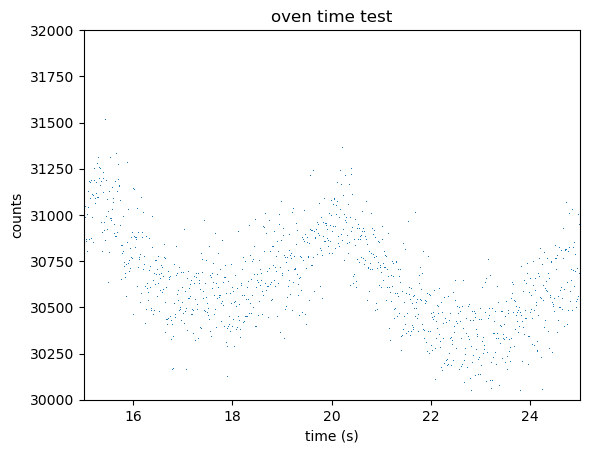

In [4]:
plt.plot(time_oven,counts_oven,',')
plt.xlabel('time (s)')
plt.ylabel('counts')
plt.title('oven time test')
plt.ylim(30000,32000)
plt.xlim(15,25)
plt.show()

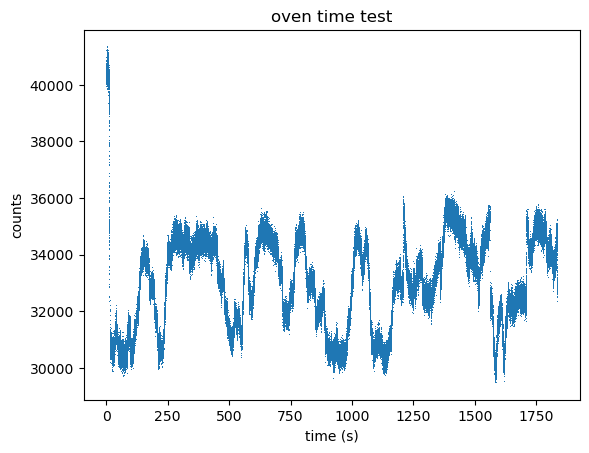

In [5]:
plt.plot(time_oven,counts_oven,',')
plt.xlabel('time (s)')
plt.ylabel('counts')
plt.title('oven time test')
#plt.ylim(30000,32000)
#plt.xlim(15,25)
plt.show()

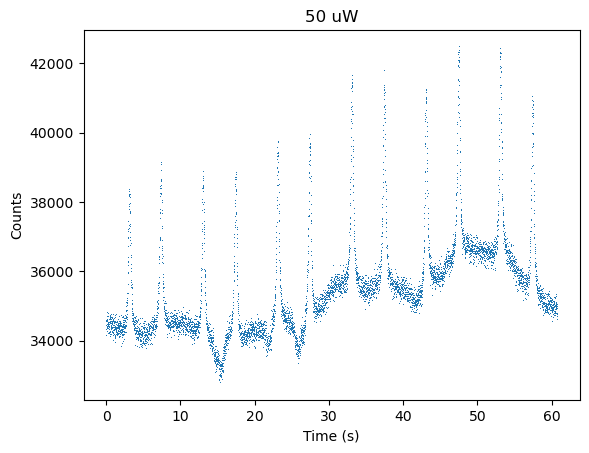

In [6]:
plt.plot(time_50uW,counts_50uW,',')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title('50 uW')
#plt.xlim(2.5,4)
plt.show()

In [7]:
def calculate_max_min_diff(time, counts, x_start=2.5, x_end=4, step=5):
    # Initialize the current x range
    current_x_start = x_start
    current_x_end = x_end

    # List to store the maximum-minimum values
    max_min_diff = []

    # Loop until the end of the list
    while current_x_end <= time[-1]:
        # Define the current x range
        x_range = (current_x_start, current_x_end)
        
        # Filter the data within the current x range
        mask = (time >= x_range[0]) & (time <= x_range[1])
        filtered_counts = counts[mask]

        # Find the maximum y value within the current x range
        max_y = filtered_counts.max()

        # Find the minimum y value within the current x range
        min_y = filtered_counts.min()

        # Calculate the difference and add to the list
        max_min_diff.append(max_y - min_y)

        #print(f"Maximum y value of counts in the range {x_range}: {max_y}")
        #print(f"Minimum y value of counts in the range {x_range}: {min_y}")
        #print(f"maximum-minimum: {max_y - min_y}")

        # Update the current x range
        current_x_start += step
        current_x_end += step

    # Calculate the average of the maximum-minimum values
    average_max_min_diff = np.mean(max_min_diff)
    print(f"Average of maximum-minimum values: {average_max_min_diff}")
    
    return average_max_min_diff

# Example usage with counts_50uW
average_max_min_diff_50uW = calculate_max_min_diff(time_50uW, counts_50uW, x_start=0, x_end=5, step=5)

Average of maximum-minimum values: 6222.0


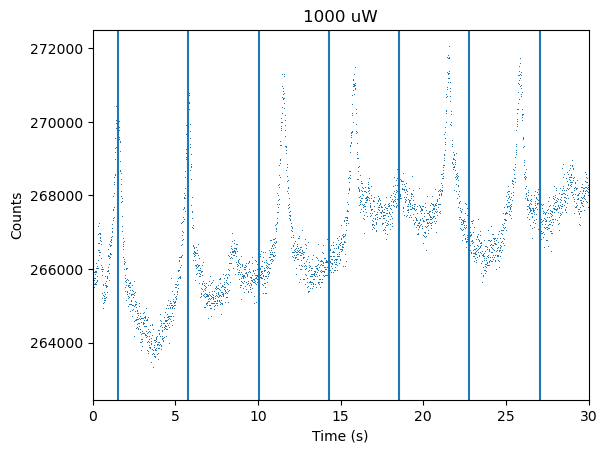

Average of maximum-minimum values: 6317.666666666667
x value where y is at its max in the x range of (0, 5): 1.54
x value where y is at its max in the x range of (5, 10): 5.79
x value where y is at its max in the x range of (10, 15): 11.56


In [8]:
plt.plot(time_1000uW,counts_1000uW,',')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title('1000 uW')
plt.xlim(0,30)
max1 = 1.54; max2 = 5.79; increment = max2 - max1
plt.axvline(max1)
plt.axvline(max1 + increment)
plt.axvline(max1 + increment*2)
plt.axvline(max1 + increment*3)
plt.axvline(max1 + increment*4)
plt.axvline(max1 + increment*5)
plt.axvline(max1 + increment*6)

plt.show()

# Example usage with counts_50uW
average_max_min_diff_1000uW = calculate_max_min_diff(time_1000uW, counts_1000uW, x_start=0, x_end=5, step=5)
# Find the x value where y is at its max in the x range of (0,5)
x_range = (0, 5)
mask = (time_1000uW >= x_range[0]) & (time_1000uW <= x_range[1])
x_max = time_1000uW[mask][np.argmax(counts_1000uW[mask])]
print(f"x value where y is at its max in the x range of {x_range}: {x_max}")
# Find the x value where y is at its max in the x range of (0,5)
x_range = (5, 10)
mask = (time_1000uW >= x_range[0]) & (time_1000uW <= x_range[1])
x_max = time_1000uW[mask][np.argmax(counts_1000uW[mask])]
print(f"x value where y is at its max in the x range of {x_range}: {x_max}")
x_range = (10, 15)
mask = (time_1000uW >= x_range[0]) & (time_1000uW <= x_range[1])
x_max = time_1000uW[mask][np.argmax(counts_1000uW[mask])]
print(f"x value where y is at its max in the x range of {x_range}: {x_max}")

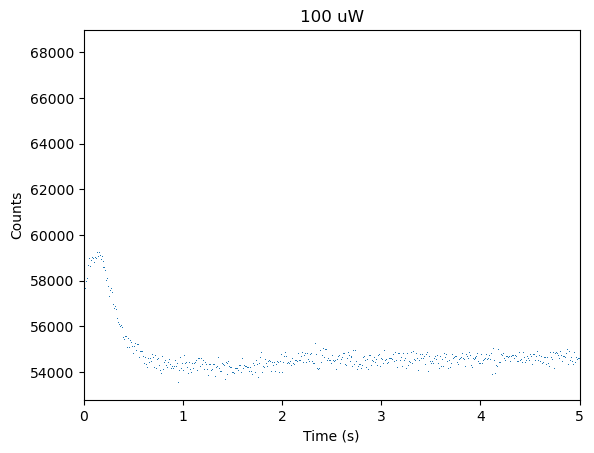

Average of maximum-minimum values: 8405.833333333334


In [9]:
plt.plot(time_100uW,counts_100uW,',')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title('100 uW')
plt.xlim(0,5)
plt.show()

# Example usage with counts_50uW
average_max_min_diff_100uW = calculate_max_min_diff(time_100uW, counts_100uW, x_start=0, x_end=5, step=5)

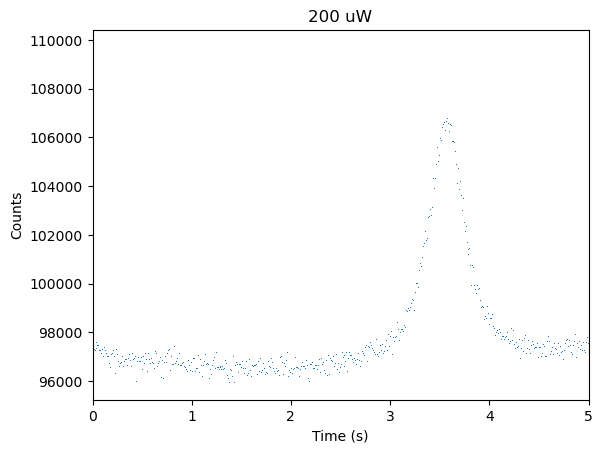

Average of maximum-minimum values: 9126.333333333334


In [10]:
plt.plot(time_200uW,counts_200uW,',')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title('200 uW')
plt.xlim(0,5)
plt.show()

# Example usage with counts_50uW
average_max_min_diff_200uW = calculate_max_min_diff(time_200uW, counts_200uW, x_start=0, x_end=5, step=5)

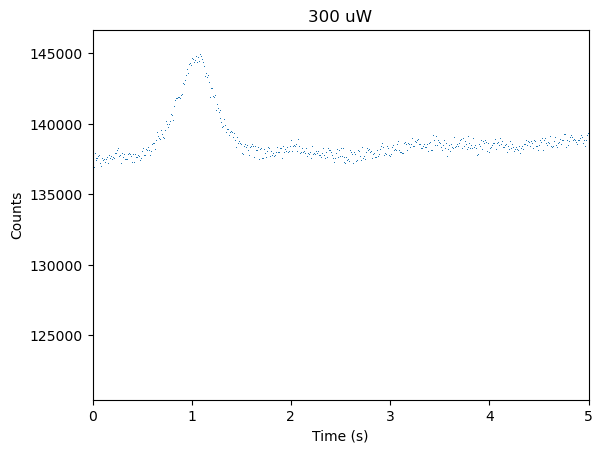

Average of maximum-minimum values: 6740.583333333333


In [11]:
plt.plot(time_300uW,counts_300uW,',')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title('300 uW')
plt.xlim(0,5)
plt.show()

# Example usage with counts_50uW
average_max_min_diff_300uW = calculate_max_min_diff(time_300uW, counts_300uW, x_start=0, x_end=5, step=5)

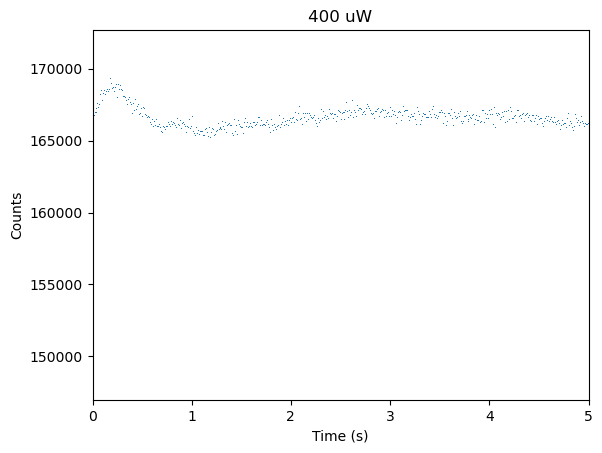

Average of maximum-minimum values: 5755.666666666667


In [12]:
plt.plot(time_400uW,counts_400uW,',')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title('400 uW')
plt.xlim(0,5)
plt.show()

# Example usage with counts_50uW
average_max_min_diff_400uW = calculate_max_min_diff(time_400uW, counts_400uW, x_start=0, x_end=5, step=5)

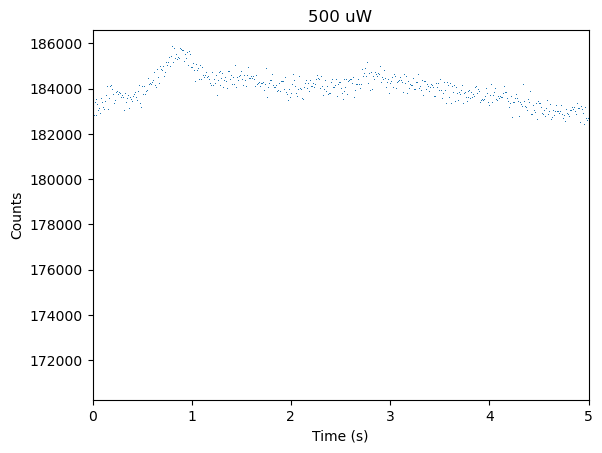

Average of maximum-minimum values: 4908.416666666667


In [13]:
plt.plot(time_500uW,counts_500uW,',')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title('500 uW')
plt.xlim(0,5)
plt.show()

# Example usage with counts_50uW
average_max_min_diff_500uW = calculate_max_min_diff(time_500uW, counts_500uW, x_start=0, x_end=5, step=5)

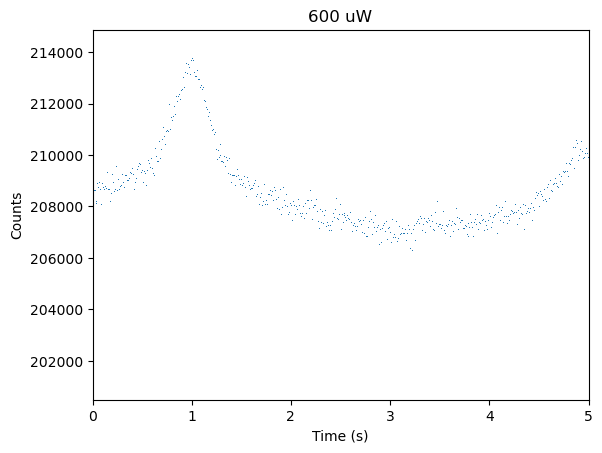

Average of maximum-minimum values: 6451.166666666667


In [14]:
plt.plot(time_600uW,counts_600uW,',')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title('600 uW')
plt.xlim(0,5)
plt.show()

# Example usage with counts_50uW
average_max_min_diff_600uW = calculate_max_min_diff(time_600uW, counts_600uW, x_start=0, x_end=5, step=5)

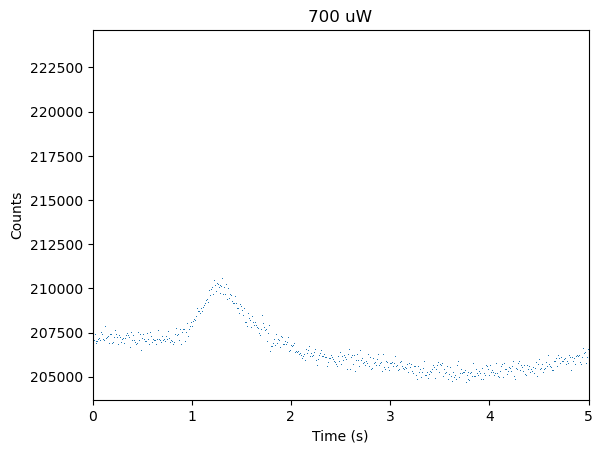

Average of maximum-minimum values: 5255.75


In [15]:
plt.plot(time_700uW,counts_700uW,',')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title('700 uW')
plt.xlim(0,5)
plt.show()

# Example usage with counts_50uW
average_max_min_diff_700uW = calculate_max_min_diff(time_700uW, counts_700uW, x_start=0, x_end=5, step=5)

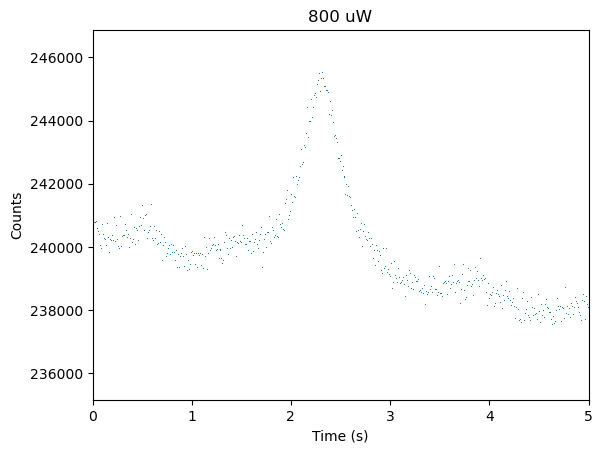

Average of maximum-minimum values: 7969.083333333333


In [16]:
plt.plot(time_800uW,counts_800uW,',')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title('800 uW')
plt.xlim(0,5)
plt.show()

# Example usage with counts_50uW
average_max_min_diff_800uW = calculate_max_min_diff(time_800uW, counts_800uW, x_start=0, x_end=5, step=5)

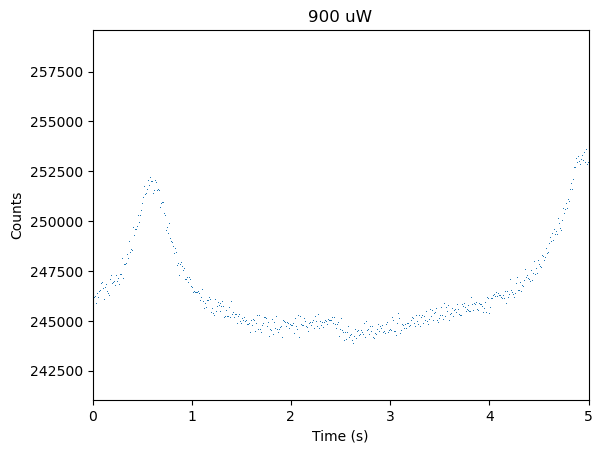

Average of maximum-minimum values: 7701.076923076923


In [17]:
plt.plot(time_900uW,counts_900uW,',')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title('900 uW')
plt.xlim(0,5)
plt.show()

# Example usage with counts_50uW
average_max_min_diff_900uW = calculate_max_min_diff(time_900uW, counts_900uW, x_start=0, x_end=5, step=5)

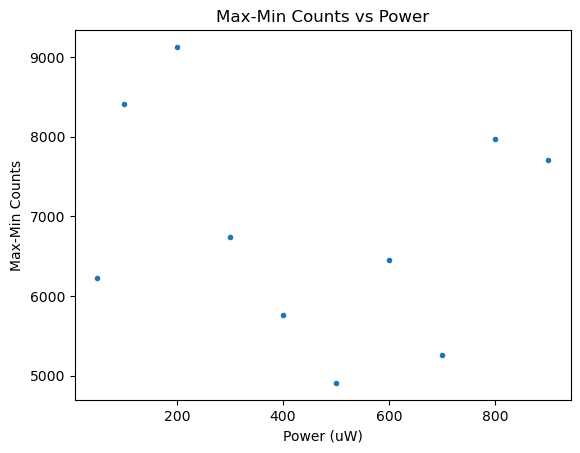

In [18]:
min_max_differences = [average_max_min_diff_50uW,average_max_min_diff_100uW,average_max_min_diff_200uW,average_max_min_diff_300uW,average_max_min_diff_400uW,average_max_min_diff_500uW,average_max_min_diff_600uW,average_max_min_diff_700uW,average_max_min_diff_800uW,average_max_min_diff_900uW]
powers = [50,100,200,300,400,500,600,700,800,900]
plt.plot(powers,min_max_differences,'.')
plt.xlabel('Power (uW)')
plt.ylabel('Max-Min Counts')
plt.title('Max-Min Counts vs Power')
plt.show()

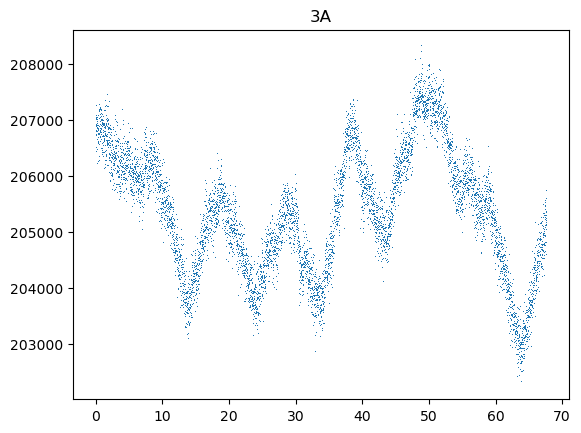

In [19]:
plt.plot(time_3A,counts_3A,',')
plt.title('3A')
#plt.xlim(10,30)
plt.savefig('3A.png')
plt.show()


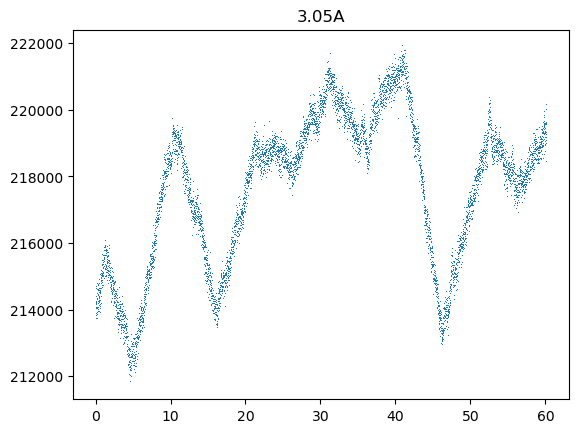

In [20]:
plt.plot(time_3_05A,counts_3_05A,',')
plt.title('3.05A')
#plt.xlim(10,30)
plt.savefig('3_05A.png')
plt.show()

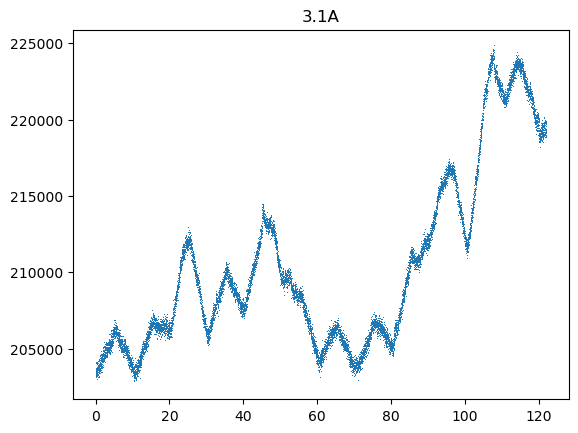

In [21]:
plt.plot(time_3_1A,counts_3_1A,',')
plt.title('3.1A')
#plt.xlim(40,60)
#plt.ylim(205000,215000)
plt.savefig('3_1A.png')
plt.show()

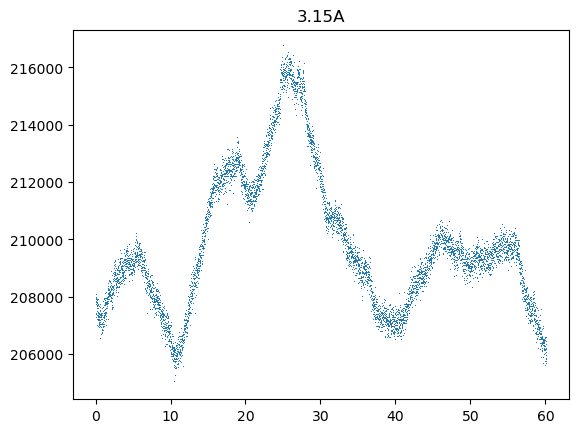

In [22]:
plt.plot(time_3_15A,counts_3_15A,',')
plt.title('3.15A')
#plt.xlim(15,30)
plt.savefig('3_15A.png')
plt.show()

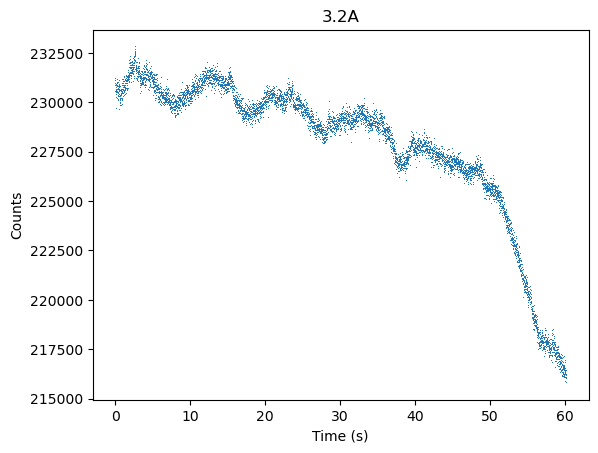

1250.0


In [23]:
plt.plot(time_3_2A,counts_3_2A,',')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title('3.2A')
"""plt.xlim(0,30)
plt.ylim(227500,233000)"""
"""plt.axhline(y=232500)
plt.axhline(y = 231000)
plt.axhline(y = 231700,color = 'g')
plt.axhline(y = 230700,color = 'g')"""
plt.savefig('3_2A.png')
plt.show()
F_3_2_avg = ((231700-230700) + (232500-231000))/2
print(F_3_2_avg)

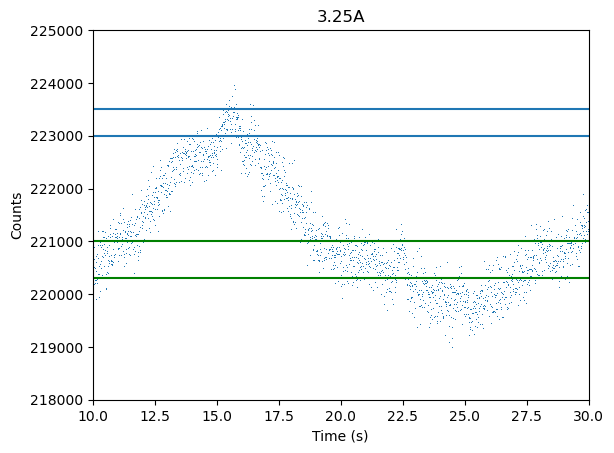

600.0


In [24]:
plt.plot(time_3_25A,counts_3_25A,',')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title('3.25A')
plt.xlim(10,30)
plt.ylim(218000,225000)
plt.axhline(y =223500)
plt.axhline(y = 223000)
plt.axhline(y = 221000,color = 'g')
plt.axhline(y = 220300,color = 'g')
plt.show()
F_3_25_avg = ((221000-220300) + (223500-223000))/2
print(F_3_25_avg)

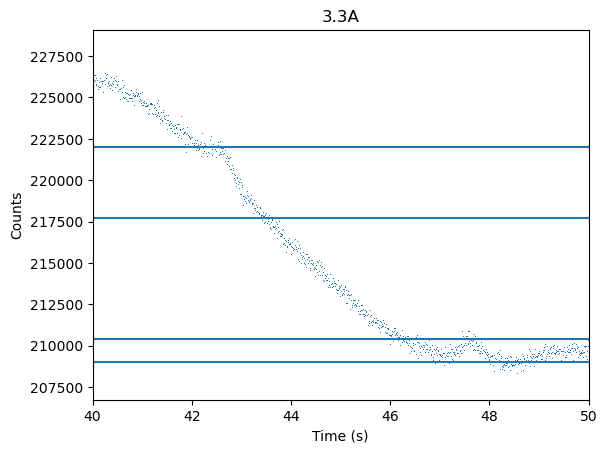

2850.0


In [25]:
plt.plot(time_3_3A,counts_3_3A,',')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
#plt.ylim(207500,217500)
#plt.ylim(208000,215000)
plt.xlim(40,50)
#plt.xlim(44,49)
#plt.ylim(207500,212500)
plt.title("3.3A")
plt.axhline(y = 222000)
plt.axhline(y = 217700)
plt.axhline(y = 209000)
plt.axhline(y = 210400)
plt.show()
F3_3_1 = 222000
F_3_3_2 = 217700
F3_3_3 = 209000
F3_3_4 = 210400
F_3_3_avg = (-F_3_3_2 + F3_3_1 + F3_3_4 - F3_3_3)/2
print(F_3_3_avg)

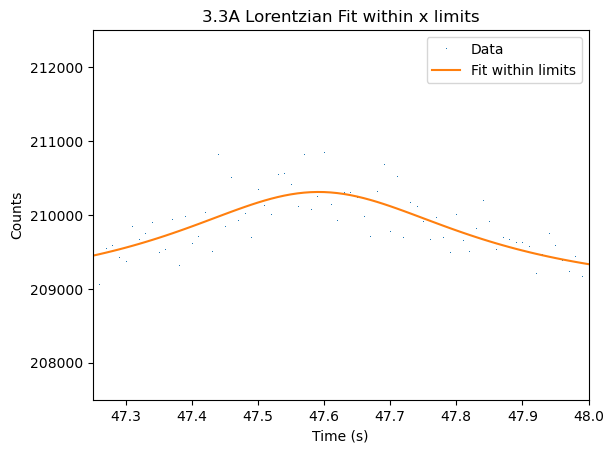

Fit parameters within x limits: [4.75917530e+01 2.73001840e-01 1.41313100e+03 2.08897353e+05]
Fit parameters within x limits: [4.75917530e+01 2.73001840e-01 1.41313100e+03 2.08897353e+05]


In [26]:
from scipy.optimize import curve_fit

# Define the Lorentzian function
def lorentzian(x, x0, gamma, a, d):
    return a * gamma**2 / ((x - x0)**2 + gamma**2) + d

# Fit the data for 3.3A
def fit_lorentzian(time, counts):
    # Initial guess for the parameters
    initial_guess = [time[np.argmax(counts)], 1, max(counts), min(counts)]
    
    # Perform the curve fitting
    popt, pcov = curve_fit(lorentzian, time, counts, p0=initial_guess)
    
    return popt, pcov


def fit_and_plot_lorentzian(time, counts, x_limits):
    # Filter the data within the x limits
    mask = (time >= x_limits[0]) & (time <= x_limits[1])
    time_fit = time[mask]
    counts_fit = counts[mask]

    # Fit the data within the x limits
    popt, pcov = fit_lorentzian(time_fit, counts_fit)
    
    # Plot the data and the fit within the x limits
    plt.plot(time, counts, ',', label='Data')
    plt.plot(time_fit, lorentzian(time_fit, *popt), '-', label='Fit within limits')
    plt.xlabel('Time (s)')
    plt.ylabel('Counts')
    plt.xlim(x_limits)
    plt.ylim(207500, 212500)
    plt.title('3.3A Lorentzian Fit within x limits')
    plt.legend()
    plt.show()

    # Print the fit parameters within the x limits
    print("Fit parameters within x limits:", popt)
    return popt, pcov

# Call the function for 3.3A data
x_limits = (47.25, 48)
popt_3_3A_limited, pcov_3_3A_limited = fit_and_plot_lorentzian(time_3_3A, counts_3_3A, x_limits)


# Print the fit parameters within the x limits
print("Fit parameters within x limits:", popt_3_3A_limited)

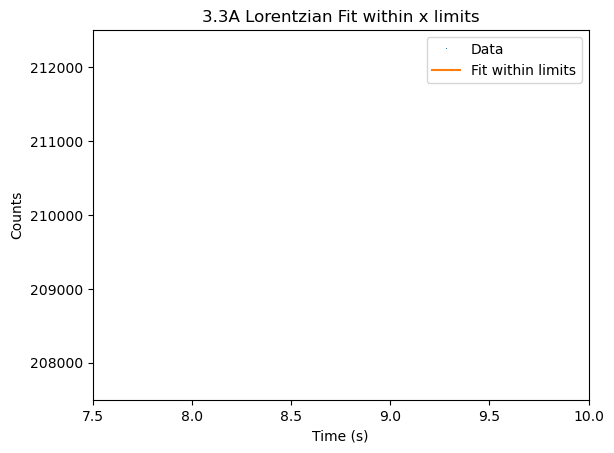

Fit parameters within x limits: [ 8.98544682e+00  2.56034957e-01 -6.14800002e+02  2.27236841e+05]
Fit parameters for 3.35A within x limits: [ 8.98544682e+00  2.56034957e-01 -6.14800002e+02  2.27236841e+05]


In [27]:
# Call the function for 3.35A data
x_limits_3_35A = (7.5, 10)
popt_3_35A, pcov_3_35A = fit_and_plot_lorentzian(time_3_35A, counts_3_35A, x_limits_3_35A)

# Print the fit parameters within the x limits
print("Fit parameters for 3.35A within x limits:", popt_3_35A)

"plt.axhline(y = 228000)\nplt.axhline(y = 227000)\nplt.axhline(y = 227500,color = 'g')\nplt.axhline(y = 226400,color = 'g')\nplt.show()\nF_3_35_avg = ((227500-226400) + (228000-227000))/2\nprint(F_3_35_avg)"

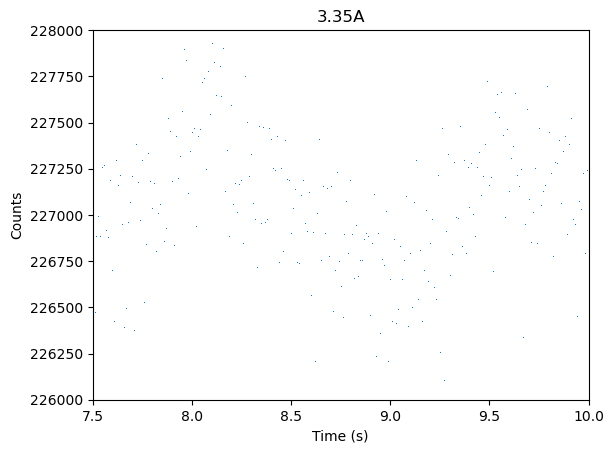

In [28]:
plt.plot(time_3_35A,counts_3_35A,',')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title('3.35A')
plt.xlim(7.5,10)
plt.ylim(226000,228000)
"""plt.axhline(y = 228000)
plt.axhline(y = 227000)
plt.axhline(y = 227500,color = 'g')
plt.axhline(y = 226400,color = 'g')
plt.show()
F_3_35_avg = ((227500-226400) + (228000-227000))/2
print(F_3_35_avg)"""

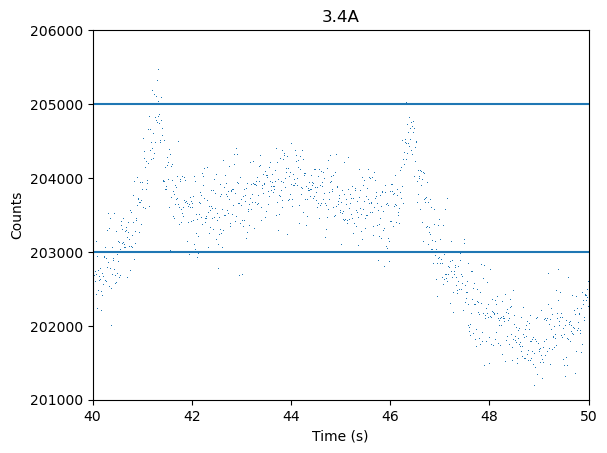

2000


In [29]:
plt.plot(time_3_4A,counts_3_4A,',')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title("3.4A")
plt.xlim(40,50)
plt.ylim(201000,206000)
plt.axhline(y = 205000)
plt.axhline(y = 203000)
plt.show()
F_3_4_1 = 205000
F_3_4_2 = 203000
F_3_4_avg = F_3_4_1 - F_3_4_2
print(F_3_4_avg)

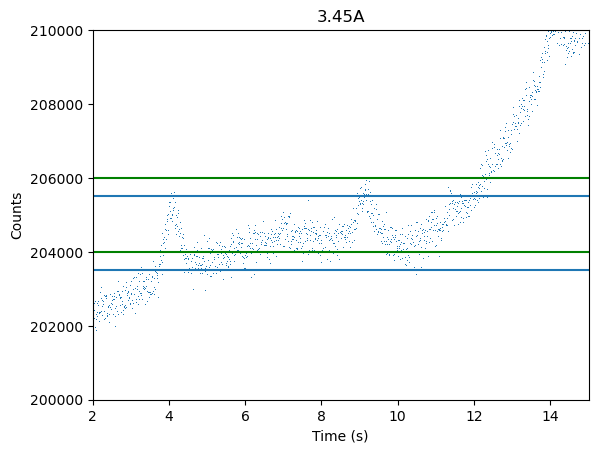

2000.0


In [30]:
plt.plot(time_3_45A,counts_3_45A,',')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title('3.45A')
plt.xlim(2,15)
plt.ylim(200000,210000)
plt.axhline(y = 203500)
plt.axhline(y = 205500)
plt.axhline(y = 206000,color = 'g')
plt.axhline(y = 204000,color = 'g')
plt.show()
F_3_45_avg = ((206000-204000) + (205500-203500))/2
print(F_3_45_avg)

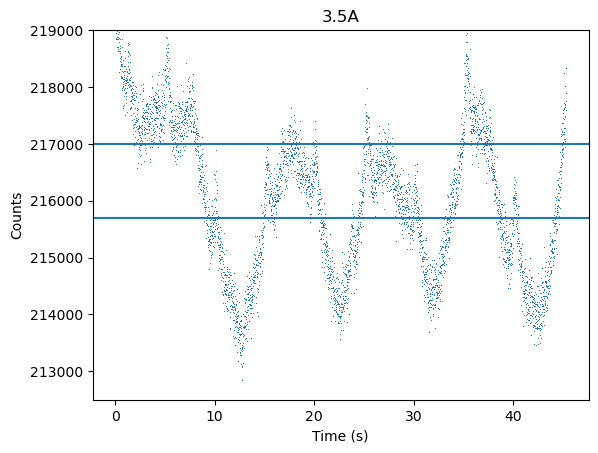

1300


In [31]:
plt.plot(time_3_5A,counts_3_5A,',')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title("3.5A")
#plt.xlim(12,25)
plt.ylim(212500,219000)
plt.axhline(y = 217000)
plt.axhline(y = 215700)
plt.show()
F_3_5_1 = 217000
F_3_5_2 = 215700
F_3_5_avg = F_3_5_1 - F_3_5_2
print(F_3_5_avg)

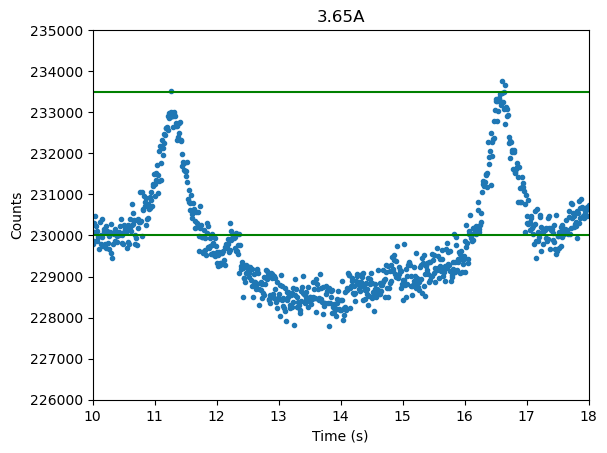

3500


In [32]:
plt.plot(time_3_65A,counts_3_65A,'.')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title('3.65A')
plt.xlim(10,18)
plt.ylim(226000,235000)
plt.axhline(230000,color = 'g')
plt.axhline(233500,color = 'g')
plt.show()
F_3_65_avg = 233500 - 230000
print(F_3_65_avg)

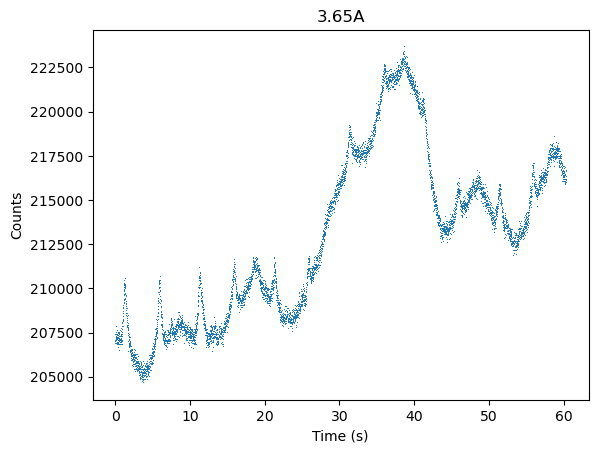

In [33]:
plt.plot(time_3_65A_again,counts_3_65A_again,',')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title('3.65A')
plt.show()

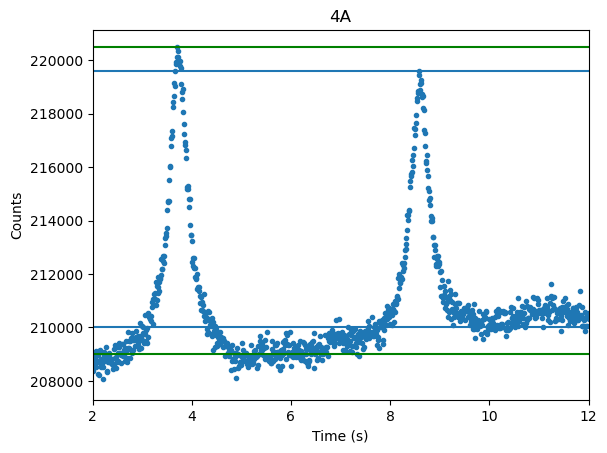

10550.0


In [34]:
plt.plot(time_4A,counts_4A,'.')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title('4A')
plt.xlim(2,12)
plt.axhline(y = 209000,color = 'g')
plt.axhline(y = 220500,color = 'g')
plt.axhline(y = 210000)
plt.axhline(y = 219600)
plt.show()
F_4_avg = (220500 - 209000 + 219600 - 210000)/2
print(F_4_avg)

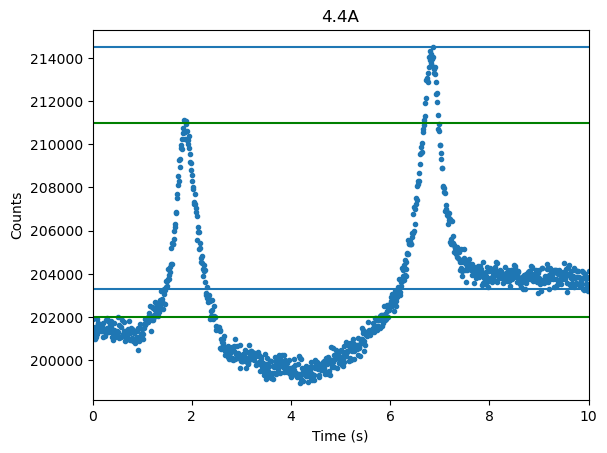

10100.0


In [35]:
plt.plot(time_4_4A,counts_4_4A,'.')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title('4.4A')
plt.xlim(0,10)
plt.axhline(202000,color = 'g')
plt.axhline(211000,color = 'g')
plt.axhline(203300)
plt.axhline(214500)
plt.show()
F_4_4_avg = (211000 - 202000 + 214500 - 203300)/2
print(F_4_4_avg)

In [36]:
plt.plot(time)

NameError: name 'time' is not defined

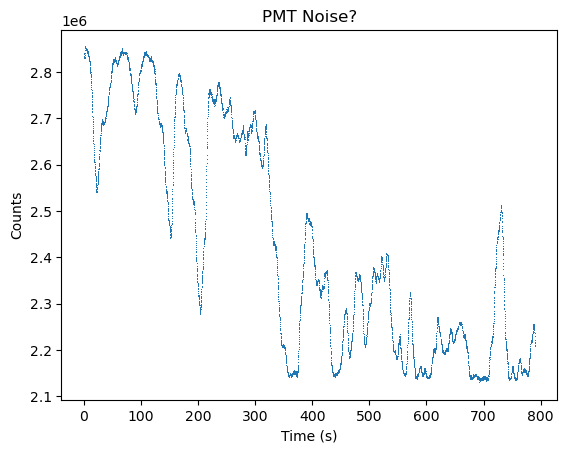

In [ ]:
plt.plot(time_test,counts_test,',')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title("PMT Noise?")
plt.show()

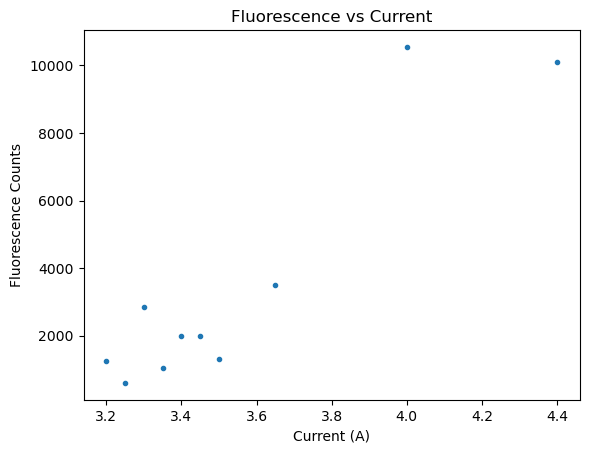

In [21]:
F = np.array([F_3_2_avg,F_3_25_avg,F_3_3_avg,F_3_35_avg,F_3_4_avg,F_3_45_avg,F_3_5_avg,F_3_65_avg,F_4_avg,F_4_4_avg])
I = np.array([3.2,3.25,3.3,3.35,3.4,3.45,3.5,3.65,4,4.4])
plt.plot(I,F,'.')
plt.xlabel('Current (A)')
plt.ylabel('Fluorescence Counts')
plt.title('Fluorescence vs Current')
plt.show()

0       2837117
1       2837666
2       2832620
3       2830903
4       2828898
         ...   
7895    2209298
7896    2205576
7897    2214791
7898    2213300
7899    2220052
Name: counts, Length: 7900, dtype: int64


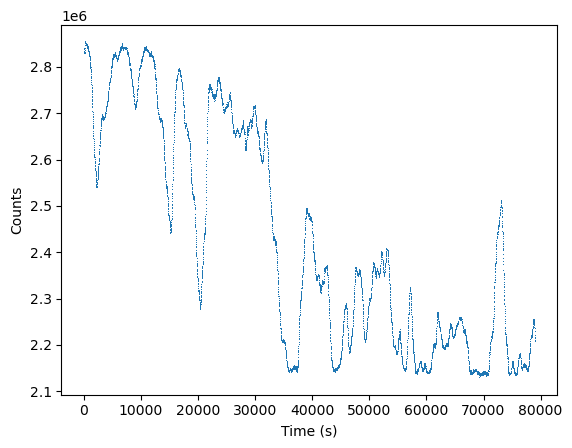